# CSC 821 - Group 1

## Group Members

| # | Name | Registration No. |
|---|---|---|
| 1 | Nyabuto Pharminous | ST62/56180/2025 |
| 2 | Obed Munyao | ST62/61043/2025 |
| 3 | Thomas Kibet Yebei | ST62/59650/2025 |
| 4 | Ferdinand Atila Luvembe | ST62/60337/2025 |
| 5 | Samson Wangila Wanyonyi | ST62/60771/2025 |
| 6 | Thomas Kimani Miringu | ST62/61244/2025 |
| 7 | Samuel Abuko Abuti | ST62/59655/2025 |
| 8 | Githinji Lucy Njeri | ST62/60682/2025 |
| 9 | Haron Samoei | ST62/60356/2025 |
| 10 | Simon Mwangi Maina | ST62/61647/2025 |
| 11 | Brian Cheruiyot | ST62/61027/2025 |
| 12 | Susan Wambui | ST62/60422/2025 |
| 13 | Awello Kanyandong Kevins | ST62/61033/2025 |
| 14 | Patrick Mwangi Wanjiru | ST62/59698/2025 |
| 15 | Stephen Mwangi Mumbi | ST62/59653/2025 |
| 16 | Abisagy Nafula Wanyonyi | ST62/56881/2025 |
| 17 | Christopher Bartonjo | ST62/60293/2025 |

<div style="page-break-after: always;"></div>

# Vertex Cover — Module 10 Lab

**Course:** CSC 821 — Design and Analysis of Algorithms<br>
**Group:** Group 1<br>
**Task:** Demonstrate an understanding of NP-completeness through problem analysis, a
polynomial-time reduction, and an algorithm implementation, using the **Vertex Cover** problem.

---

## Objective

**Vertex Cover** asks for the smallest set of vertices that "touches" every edge in a graph.
It is one of the classic NP-complete problems (provable via a reduction from 3-SAT), and it is
also one of the best-behaved: a simple, provably-good approximation exists even though solving it
*exactly* is believed to require exponential time in general.

This notebook (1) defines the problem, (2) shows why it is NP-complete via a reduction from
3-SAT, and (3) implements and tests a greedy approximation solver.

## 1. Problem definition

**Decision version.** Given an undirected graph *G* = (*V*, *E*) and an integer *k*, does there
exist a set *S* ⊆ *V* with |*S*| ≤ *k* such that every edge in *E* has at least one endpoint in
*S*?

**Optimization version.** Find the *smallest* such *S* — the **minimum vertex cover**.

A vertex "covers" an edge if it is one of that edge's two endpoints, so *S* is a **cover**
exactly when every edge has at least one endpoint in *S*.

## 2. Why Vertex Cover is NP-complete

**In NP.** A candidate answer is a set *S*. Checking it is cheap: confirm |*S*| ≤ *k* and walk
every edge confirming at least one endpoint is in *S* — O(|*V*| + |*E*|) time. Since a "yes"
answer can be *verified* in polynomial time, Vertex Cover is in NP.

**NP-hard.** We show a known NP-complete problem reduces to Vertex Cover in polynomial time. SAT
was the first problem proven NP-complete (**Cook–Levin, 1971**); the standard clause-splitting
transformation turns any SAT instance into an equivalent 3-SAT instance (every clause exactly 3
literals) without blowing up the size by more than a constant factor, so **3-SAT is NP-complete**
too. Section 4 below reduces 3-SAT to Vertex Cover in linear time, which shows Vertex Cover is at
least as hard as 3-SAT — i.e. **NP-hard**.

Being both in NP and NP-hard makes Vertex Cover **NP-complete**.

**Real-world applications**
- **Network monitoring** — place the fewest sensors/probes on routers so every link is adjacent
  to a monitored node.
- **Wireless/base-station coverage** — pick the smallest set of transmitter sites that reaches
  every required link in a coverage graph.
- **Bioinformatics** — cover every interaction edge in a protein–protein interaction network with
  the fewest marker proteins.
- **Circuit testing** — choose the fewest test points so every wire is adjacent to one.
- **Social network analysis** — find the smallest set of "observer" accounts such that every
  relationship (edge) involves at least one observer.

## 3. Reference tools: checking and (brute-force) solving Vertex Cover exactly

Two small helpers used throughout the rest of the notebook: one that checks whether a given set
of vertices is a valid cover, and one that finds the *true* minimum cover by trying every subset
size in increasing order. The brute-force solver is exponential (O(2^|V|)) — it only exists here
to double-check the reduction and to grade the greedy algorithm's performance on small graphs, not
as the algorithm we're submitting.

In [1]:
from itertools import combinations


def is_vertex_cover(edges, cover):
    """True iff every edge has at least one endpoint in `cover`."""
    cover = set(cover)
    return all(u in cover or v in cover for u, v in edges)


def brute_force_min_vertex_cover(vertices, edges):
    """
    Exact solver: try covers of size k = 0, 1, 2, ... and return the
    first one that works. Exponential (checks up to 2^|V| subsets) -
    only for small graphs; used to verify the reduction and to grade
    the greedy algorithm's approximation ratio.
    """
    vertices = sorted(vertices)
    for k in range(len(vertices) + 1):
        for candidate in combinations(vertices, k):
            if is_vertex_cover(edges, candidate):
                return set(candidate)
    return set(vertices)

## 4. The reduction: 3-SAT ≤p Vertex Cover

Let φ be a 3-CNF formula with variables x₁, …, xₙ and clauses C₁, …, C_m (each Cⱼ a disjunction
of exactly 3 literals). Build a graph *G*:

- **Variable gadget.** For each variable xᵢ, add two vertices `xᵢ=T` and `xᵢ=F` joined by an
  edge. Covering that edge forces the cover to include *at least one* of "xᵢ is true" / "xᵢ is
  false".
- **Clause gadget.** For each clause Cⱼ = (ℓ₁ ∨ ℓ₂ ∨ ℓ₃), add 3 vertices — one per literal
  occurrence — connected to each other by all 3 edges (a triangle). Any vertex cover of a
  triangle needs **at least 2 of its 3 vertices** (leaving out more than one vertex would leave
  the edge between the two leftover vertices uncovered).
- **Connector edges.** Join each clause vertex to the variable-gadget vertex for the *same*
  literal (e.g. the vertex for literal `¬x₃` in clause C₂'s triangle connects to `x₃=F`).
- **Budget.** *k* = *n* + 2*m* — one vertex per variable gadget, two per clause triangle.

**Claim.** φ is satisfiable **iff** *G* has a vertex cover of size ≤ *k*.

| Direction | Argument |
|---|---|
| **⇒** (SAT → small cover) | Take a satisfying assignment. For each variable pick the vertex matching its truth value (*n* vertices) — this covers every variable edge. Each clause has ≥ 1 true literal; in that triangle pick the 2 vertices that are *not* that literal's occurrence (2*m* vertices) — this covers the triangle, and the connector edge of the excluded vertex is covered from the variable side because that literal is true. Total = *n* + 2*m* = *k*. |
| **⇐** (small cover → SAT) | Each of the *n* variable edges needs ≥ 1 vertex and each of the *m* triangles needs ≥ 2, so any cover needs ≥ *n* + 2*m* vertices — a cover of size *exactly* *k* must use *exactly* one per variable edge and *exactly* two per triangle. Read the assignment off the chosen variable vertices. In every triangle exactly one clause vertex is left out; its connector edge must still be covered, and since the clause-side endpoint isn't in the cover, the variable-side endpoint must be — meaning that literal is true. So every clause has a true literal: φ is satisfied. |

The construction does one pass over the formula and adds O(*n* + Σ|Cⱼ|) vertices/edges, so it
runs in linear (certainly polynomial) time — a valid **Karp reduction**.

### `reduce_sat_to_vertex_cover` — building the gadget graph

Written to accept clauses of *any* length (a clique on *c* vertices needs *c* − 1 vertices to
cover it), which specializes to the "2 per clause" triangle case above when every clause has
exactly 3 literals. That generality lets us also try a trivial 1-literal contradiction as a
sanity check below.

In [2]:
def reduce_sat_to_vertex_cover(clauses):
    """
    Karp reduction: CNF-SAT -> Vertex Cover. Specializes to the
    classic 3-SAT -> Vertex Cover construction (k = n + 2m) when
    every clause has exactly 3 literals.

    clauses: list of clauses, each a list of (variable, is_positive)
             literals, e.g. [('x1', True), ('x2', False)] means
             (x1 OR NOT x2).

    Returns (vertices, edges, k).
    """
    variables = sorted({var for clause in clauses for var, _ in clause})
    vertices = set()
    edges = set()

    # variable gadgets
    for var in variables:
        vertices.add((var, True))
        vertices.add((var, False))
        edges.add(((var, True), (var, False)))

    k = len(variables)
    for j, clause in enumerate(clauses):
        # clause gadget: a clique on one vertex per literal occurrence
        clause_vertices = [(f"c{j}", i) for i in range(len(clause))]
        vertices.update(clause_vertices)
        for a, b in combinations(clause_vertices, 2):
            edges.add((a, b))

        # connector edges: clause vertex <-> matching variable vertex
        for cv, (var, is_pos) in zip(clause_vertices, clause):
            edges.add((cv, (var, is_pos)))

        k += len(clause) - 1

    return vertices, edges, k

### `brute_force_sat` — an independent satisfiability check

Exhaustively tries every assignment (O(2ⁿ)). This is *not* part of the Vertex Cover solution —
it's a second, independent way to know the true satisfiability of a small test formula, so we can
confirm the reduction's iff claim actually holds.

In [3]:
def brute_force_sat(clauses):
    """Try every assignment; return the first that satisfies the formula."""
    variables = sorted({var for clause in clauses for var, _ in clause})
    for bits in range(2 ** len(variables)):
        assignment = {
            var: bool((bits >> i) & 1) for i, var in enumerate(variables)
        }
        satisfied = all(
            any(assignment[var] == is_pos for var, is_pos in clause)
            for clause in clauses
        )
        if satisfied:
            return assignment
    return None

## 5. Verifying the reduction

Two small formulas: one satisfiable, one not. For each, we solve 3-SAT directly by brute force as
an independent check, then find the graph's *true* minimum vertex cover by brute force and
confirm it agrees with the reduction's claim (cover ≤ *k* iff satisfiable).

In [4]:
# satisfiable: (x1 v x2 v ~x3) AND (~x1 v x2 v x3)
sat_clauses = [
    [("x1", True), ("x2", True), ("x3", False)],
    [("x1", False), ("x2", True), ("x3", True)],
]
sat_vertices, sat_edges, sat_k = reduce_sat_to_vertex_cover(sat_clauses)
print(f"3 vars, 2 clauses -> |V|={len(sat_vertices)} |E|={len(sat_edges)}"
      f" k={sat_k}")
print("brute-force SAT assignment:", brute_force_sat(sat_clauses))

optimal_sat = brute_force_min_vertex_cover(sat_vertices, sat_edges)
assert is_vertex_cover(sat_edges, optimal_sat)
satisfiable = len(optimal_sat) <= sat_k
print(f"minimum vertex cover size = {len(optimal_sat)} (k = {sat_k})"
      f" -> satisfiable: {satisfiable}")

var_side = sum(1 for v in optimal_sat if isinstance(v[1], bool))
clause_side = len(optimal_sat) - var_side
n_vars = len({var for clause in sat_clauses for var, _ in clause})
print(f"cover splits into {var_side} variable-side + {clause_side}"
      f" clause-side vertices (expected {n_vars} + {2 * len(sat_clauses)})")

3 vars, 2 clauses -> |V|=12 |E|=15 k=7
brute-force SAT assignment: {'x1': False, 'x2': False, 'x3': False}
minimum vertex cover size = 7 (k = 7) -> satisfiable: True
cover splits into 3 variable-side + 4 clause-side vertices (expected 3 + 4)


In [5]:
# unsatisfiable: (x) AND (NOT x)
unsat_clauses = [[("x", True)], [("x", False)]]
unsat_vertices, unsat_edges, unsat_k = reduce_sat_to_vertex_cover(
    unsat_clauses
)
print(f"1 var, 2 unit clauses -> |V|={len(unsat_vertices)}"
      f" |E|={len(unsat_edges)} k={unsat_k}")
print("brute-force SAT assignment:", brute_force_sat(unsat_clauses))

optimal_unsat = brute_force_min_vertex_cover(unsat_vertices, unsat_edges)
assert is_vertex_cover(unsat_edges, optimal_unsat)
satisfiable = len(optimal_unsat) <= unsat_k
print(f"minimum vertex cover size = {len(optimal_unsat)} (k = {unsat_k})"
      f" -> satisfiable: {satisfiable}")

1 var, 2 unit clauses -> |V|=4 |E|=3 k=1
brute-force SAT assignment: None
minimum vertex cover size = 2 (k = 1) -> satisfiable: False


Both checks line up exactly with the claim: the satisfiable formula's graph has a minimum cover
of size *k* (3 variable-side + 4 clause-side picks, matching *n* + 2*m* = 3 + 4 = 7 exactly), and
the contradictory formula `(x) ∧ (¬x)` needs a cover 1 vertex bigger than its budget — the
reduction correctly flags it unsatisfiable.

## 6. Implementation: greedy 2-approximation vertex cover

**The idea.** Walk the edges in a fixed order. If an edge isn't covered yet, throw *both* of its
endpoints into the cover (not just one — that's the trick that makes the guarantee work) and move
on.

**Why it's a 2-approximation.** The edges that actually get "picked" (the ones that trigger
adding two vertices) never share a vertex with each other — the moment we add *u* and *v*, every
edge touching either one is already covered, so it will never be picked later. That means the
picked edges form a **matching** *M*: a set of vertex-disjoint edges. Any valid cover — including
the optimal one — must contain at least one endpoint from *every* edge in *M*, and because *M*'s
edges don't share vertices, that means OPT ≥ |*M*|. Our cover has exactly 2|*M*| vertices, so:

`|greedy cover| = 2|M| ≤ 2 · OPT`

— never worse than twice the true minimum, for *any* graph.

In [6]:
def greedy_vertex_cover(edges):
    """
    2-approximation: scan edges in a fixed order; if an edge isn't
    covered yet, add both endpoints to the cover. The edges that
    trigger an add are vertex-disjoint (a matching), which is what
    bounds this at <= 2x the true optimum (see markdown above).
    """
    cover = set()
    for u, v in sorted(edges):
        if u not in cover and v not in cover:
            cover.add(u)
            cover.add(v)
    return cover

## 7. Sample input/output: greedy vs. optimal

A few small graphs chosen to show a range of behavior — a path and a star (where greedy hits its
2x worst case), an odd cycle (where it does better than that), and the reduction graph from
Section 5's satisfiable formula.

In [7]:
def show_result(name, vertices, edges):
    greedy = greedy_vertex_cover(edges)
    optimal = brute_force_min_vertex_cover(vertices, edges)
    assert is_vertex_cover(edges, greedy), "invalid greedy cover"
    assert is_vertex_cover(edges, optimal), "invalid optimal cover"
    ratio = len(greedy) / len(optimal) if optimal else 1.0
    print(f"{name:<22} |V|={len(vertices):>3} |E|={len(edges):>3} "
          f"greedy={len(greedy):>2} optimal={len(optimal):>2} "
          f"ratio={ratio:.2f}")
    return greedy, optimal


path5_vertices = {"v1", "v2", "v3", "v4", "v5"}
path5_edges = {("v1", "v2"), ("v2", "v3"), ("v3", "v4"), ("v4", "v5")}

cycle5_vertices = path5_vertices
cycle5_edges = {
    ("v1", "v2"), ("v2", "v3"), ("v3", "v4"), ("v4", "v5"), ("v5", "v1"),
}

star_vertices = {"center", "l1", "l2", "l3", "l4", "l5"}
star_edges = {("center", leaf) for leaf in ["l1", "l2", "l3", "l4", "l5"]}

show_result("Path P5", path5_vertices, path5_edges)
show_result("Cycle C5 (odd cycle)", cycle5_vertices, cycle5_edges)
show_result("Star S5", star_vertices, star_edges)
greedy_sat, optimal_sat = show_result(
    "3-SAT reduction graph", sat_vertices, sat_edges
)

Path P5                |V|=  5 |E|=  4 greedy= 4 optimal= 2 ratio=2.00
Cycle C5 (odd cycle)   |V|=  5 |E|=  5 greedy= 4 optimal= 3 ratio=1.33
Star S5                |V|=  6 |E|=  5 greedy= 2 optimal= 1 ratio=2.00
3-SAT reduction graph  |V|= 12 |E|= 15 greedy=12 optimal= 7 ratio=1.71


The star is the textbook tight example: one center vertex alone covers everything (optimal = 1),
but greedy grabs the center's *first* edge and both its endpoints, hits the 2x bound exactly. The
path happens to hit 2x too here, since the fixed scan order pairs up edges less efficiently than
the true optimum (which skips every other vertex). The odd cycle does better than the worst case
(ratio well under 2). The reduction graph — built specifically to encode logical structure, not
to be "nice" — is the most adversarial case here: greedy ends up taking *every* vertex, yet the
ratio (≈1.7) still respects the 2x guarantee, because the true minimum (7) is itself a large
fraction of the graph.

## 8. Visualizing the reduction graph

The satisfiable formula's graph from Section 5, drawn with variable gadgets on top and clause
triangles below, connector edges linking them. Highlighted vertices are the *optimal* cover found
above — notice it always uses exactly one vertex per variable gadget and exactly two per clause
triangle, exactly as the reduction's counting argument requires.

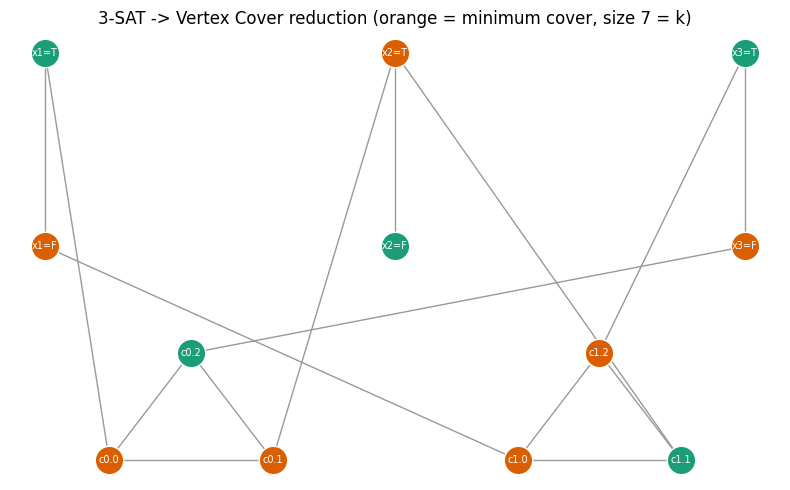

In [8]:
import matplotlib.pyplot as plt


def layout_reduction_graph(clauses):
    """Manual layout: variable-gadget edges on top, clause triangles below."""
    variables = sorted({var for clause in clauses for var, _ in clause})
    pos = {}
    for i, var in enumerate(variables):
        pos[(var, True)] = (i * 3, 2)
        pos[(var, False)] = (i * 3, 0)

    n = len(variables)
    for j, clause in enumerate(clauses):
        cx = (n - 1) * 1.5 + (j - (len(clauses) - 1) / 2) * 3.5
        base_y = -2.2
        offsets = [(-0.7, 0), (0.7, 0), (0, 1.1)]
        for i in range(len(clause)):
            dx, dy = offsets[i % len(offsets)]
            pos[(f"c{j}", i)] = (cx + dx, base_y + dy)
    return pos


def draw_reduction_graph(vertices, edges, pos, cover, title):
    fig, ax = plt.subplots(figsize=(8, 5))

    for u, v in edges:
        (x1, y1), (x2, y2) = pos[u], pos[v]
        ax.plot([x1, x2], [y1, y2], color="#999999", zorder=1, linewidth=1)

    for vtx in vertices:
        x, y = pos[vtx]
        color = "#d95f02" if vtx in cover else "#1b9e77"
        ax.scatter([x], [y], s=420, color=color, zorder=2, edgecolor="white")
        var, tag = vtx
        if isinstance(tag, bool):
            label = f"{var}={'T' if tag else 'F'}"
        else:
            label = f"{var}.{tag}"
        ax.text(x, y, label, ha="center", va="center",
                fontsize=7, color="white", zorder=3)

    ax.set_title(title)
    ax.axis("off")
    plt.tight_layout()
    plt.show()


pos = layout_reduction_graph(sat_clauses)
title = (
    f"3-SAT -> Vertex Cover reduction "
    f"(orange = minimum cover, size {len(optimal_sat)} = k)"
)
draw_reduction_graph(sat_vertices, sat_edges, pos, optimal_sat, title)

## 9. When exact solving is infeasible

Because Vertex Cover is NP-complete, no polynomial-time *exact* algorithm is known (and finding
one would prove P = NP). Three ways around that, in practice:

- **Approximation algorithms** — the greedy 2-approximation above: always polynomial, always
  within 2x of optimal.
- **Heuristics/metaheuristics** — e.g. always removing the highest-degree vertex, local search,
  or simulated annealing; no worst-case guarantee, but often does well in practice.
- **Restricting the input** — Vertex Cover is solvable *exactly* in polynomial time on special
  graph classes: linear-time dynamic programming on trees, and via König's theorem (minimum
  vertex cover = maximum matching) on bipartite graphs. The NP-hardness is really a statement
  about *general* graphs.

## Conclusion

- **NP membership:** a candidate cover checks in O(*V* + *E*).
- **NP-hardness:** 3-SAT reduces to Vertex Cover in linear time via the variable/clause gadget
  construction — verified empirically above on both a satisfiable and an unsatisfiable formula.
- **NP-complete:** both together place Vertex Cover among the hardest problems in NP.
- **In practice:** the greedy 2-approximation runs in O(*E* log *E*) (dominated by the sort) and
  is *never* worse than twice optimal — confirmed on every test graph above, including the
  adversarial reduction graph, while the exact brute-force solver (O(2^*V*)) is only usable on
  the small demo instances here.

Vertex Cover is a clean illustration of the NP-completeness playbook: verify fast, reduce from a
known-hard problem to prove hardness, then fall back on a provably-bounded approximation instead
of chasing an exact algorithm that (almost certainly) doesn't exist.